# Integrated Dietary Network Analysis
## GGM Analysis와 Co-occurrence/Centrality Analysis의 통합

본 노트북은 두 가지 네트워크 분석 방법론의 결과를 통합하여 한국인의 식습관 패턴을 종합적으로 이해합니다:

1. **Gaussian Graphical Model (GGM)**: 식품 간의 조건부 독립성을 기반으로 한 부분상관 네트워크
2. **Co-occurrence & Centrality Analysis**: 실제 섭취 동시성과 중심성 분석

### 분석 목표
- GGM에서 발견된 커뮤니티와 Co-occurrence 패턴 비교
- 두 방법론에서 일관되게 나타나는 핵심 식품군 식별
- MetS와 관련된 식습관 패턴의 통합적 이해
- 방법론 간 차이점과 보완점 파악

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from scipy import stats
from scipy.stats import spearmanr
import json

plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 10)

Matplotlib is building the font cache; this may take a moment.


## 1. 데이터 로딩 및 전처리

In [2]:
# Load data
data = pd.read_csv("../db/processed_data/total_only_org.csv")

# Extract food groups (detailed 19 variables for GGM)
food_groups_detailed = data.iloc[:, 35:54]
food_names_detailed = food_groups_detailed.columns

# Extract aggregated 12 food groups (for co-occurrence)
food_groups_agg = data.iloc[:, 15:27]
food_names_agg = food_groups_agg.columns

# Extract health variables
health_vars = data[['BMI(kg/m2)', 'Systolic blood pressure (mmHg)',
                    'Diastolic Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)',
                    'Triglycerides (mg/dL)', 'LDL-C (mg/dL)', 'HDL-C (mg/dL)',
                    'Fasting glucose (mg/dL)']]
health_vars.columns = ['BMI', 'SBP', 'DBP', 'TC', 'TG', 'LDL', 'HDL', 'FG']

# Extract MetS components
mets_components = data[['Increased waist circumference', 'Elevated blood pressure',
                        'Impaired fasting glucose', 'Elevated triglycerides',
                        'Decreased HDL-C', 'MetS']]
mets_components.columns = ['WC', 'U_BP', 'IFG', 'U_TG', 'D_HDL', 'MetS']

# Combine data
combined_data = pd.concat([food_groups_detailed, food_groups_agg, health_vars, mets_components], axis=1)
combined_data = combined_data.dropna()

print(f"Total sample size: {len(combined_data):,}")
print(f"Detailed food variables (GGM): {len(food_names_detailed)}")
print(f"Aggregated food groups (Co-occurrence): {len(food_names_agg)}")
print(f"\nMetS prevalence: {combined_data['MetS'].sum()} ({combined_data['MetS'].mean()*100:.1f}%)")

Total sample size: 23,040
Detailed food variables (GGM): 19
Aggregated food groups (Co-occurrence): 12

MetS prevalence: 5939 (25.8%)


## 2. Variable Mapping between Detailed and Aggregated Food Groups

GGM 분석에서 사용한 19개 세부 식품군과 Co-occurrence 분석에서 사용한 12개 통합 식품군의 관계를 매핑합니다.

In [3]:
# Create mapping between detailed and aggregated food groups
variable_mapping = {
    # Grains
    'White Rice': 'Grains',
    'Other grains': 'Grains',
    'Noodles and dumplings': 'Grains',
    'Bread and snacks': 'Grains',
    
    # Meat, Fish, Eggs, Legumes
    'Meat': 'Meat, fish, eggs, and legumes',
    'Fish and shellfish': 'Meat, fish, eggs, and legumes',
    'Eggs': 'Meat, fish, eggs, and legumes',
    'Legumes': 'Meat, fish, eggs, and legumes',
    
    # Vegetables
    'Vegetables': 'Vegetables',
    'Kimchi': 'Vegetables',
    
    # Fruits
    'Fruits': 'Fruits',
    
    # Dairy
    'Milk': 'Milk and dairy products',
    
    # Oils and Fats
    'Oils and fats': 'Oils and fats',
    
    # Beverages
    'Beverage': 'Beverages',
    'Alcohol': 'Beverages',
    
    # Seasonings
    'Sugars and sweeteners': 'Seasonings',
    'Seasoning': 'Seasonings',
    
    # Processed foods
    'Instant foods': 'Instant foods'
}

# Create reverse mapping (aggregated -> detailed list)
agg_to_detailed = {}
for detailed, aggregated in variable_mapping.items():
    if aggregated not in agg_to_detailed:
        agg_to_detailed[aggregated] = []
    agg_to_detailed[aggregated].append(detailed)

print("=== Variable Mapping: Aggregated Food Groups -> Detailed Variables ===")
for agg_group, detailed_list in sorted(agg_to_detailed.items()):
    print(f"\n{agg_group}:")
    for detail in detailed_list:
        print(f"  - {detail}")

=== Variable Mapping: Aggregated Food Groups -> Detailed Variables ===

Beverages:
  - Beverage
  - Alcohol

Fruits:
  - Fruits

Grains:
  - White Rice
  - Other grains
  - Noodles and dumplings
  - Bread and snacks

Instant foods:
  - Instant foods

Meat, fish, eggs, and legumes:
  - Meat
  - Fish and shellfish
  - Eggs
  - Legumes

Milk and dairy products:
  - Milk

Oils and fats:
  - Oils and fats

Seasonings:
  - Sugars and sweeteners
  - Seasoning

Vegetables:
  - Vegetables
  - Kimchi


## 3. GGM Analysis: Gaussian Graphical Model

### 3.1 Nonparanormal Transformation and GGM Construction

In [4]:
# Nonparanormal transformation function
def npn_transform(data):
    """
    Apply nonparanormal transformation
    Transforms each variable to approximate normality using rank-based transformation
    """
    transformed = data.copy()
    n = len(data)
    
    for col in data.columns:
        # Rank transformation
        ranks = stats.rankdata(data[col])
        # Transform to (0,1)
        ranks_scaled = ranks / (n + 1)
        # Apply inverse normal CDF
        transformed[col] = stats.norm.ppf(ranks_scaled)
    
    return transformed

# Apply NPN transformation
food_data_detailed = combined_data[food_names_detailed]
food_data_transformed = npn_transform(food_data_detailed)

print("=== Nonparanormal Transformation Applied ===")
print(f"Original data shape: {food_data_detailed.shape}")
print(f"Transformed data shape: {food_data_transformed.shape}")
print(f"\nSkewness comparison (first 5 variables):")
print("\nOriginal:")
print(food_data_detailed.iloc[:, :5].skew())
print("\nTransformed:")
print(food_data_transformed.iloc[:, :5].skew())

=== Nonparanormal Transformation Applied ===
Original data shape: (23040, 19)
Transformed data shape: (23040, 19)

Skewness comparison (first 5 variables):

Original:
Meal Frequency         -0.908178
Meal Portion Size      -0.060311
Eating Out Frequency    0.112260
Rice Portion Size      -0.055449
Snacking Frequency     -0.047930
dtype: float64

Transformed:
Meal Frequency         -0.797348
Meal Portion Size      -0.000114
Eating Out Frequency    0.030054
Rice Portion Size       0.017990
Snacking Frequency     -0.041297
dtype: float64


In [5]:
# Standardize transformed data
scaler = StandardScaler()
food_data_scaled = scaler.fit_transform(food_data_transformed)

# Fit Graphical Lasso
print("\n=== Fitting Gaussian Graphical Model ===")
gl_cv = GraphicalLassoCV(cv=5, max_iter=1000, tol=1e-4, n_jobs=-1)
gl_cv.fit(food_data_scaled)

# Calculate partial correlation matrix
precision_matrix = gl_cv.precision_
partial_corr_matrix = -precision_matrix / np.sqrt(np.outer(np.diag(precision_matrix), np.diag(precision_matrix)))
np.fill_diagonal(partial_corr_matrix, 1)

print(f"Optimal alpha: {gl_cv.alpha_:.4f}")
print(f"Precision matrix shape: {precision_matrix.shape}")

# Apply threshold for sparse network (for community detection)
threshold = 0.05
n_vars = len(food_names_detailed)
significant_edges = np.abs(partial_corr_matrix) > threshold
np.fill_diagonal(significant_edges, False)

print(f"\nPartial correlation threshold: {threshold}")
print(f"Significant edges: {np.sum(significant_edges) // 2}")
print(f"Network density: {(np.sum(significant_edges) // 2) / (n_vars * (n_vars - 1) // 2):.3f}")


=== Fitting Gaussian Graphical Model ===


Optimal alpha: 0.0009
Precision matrix shape: (19, 19)

Partial correlation threshold: 0.05
Significant edges: 56
Network density: 0.327


In [6]:
# Create GGM network
G_ggm = nx.Graph()
for i, food in enumerate(food_names_detailed):
    G_ggm.add_node(food)

edge_weights_ggm = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if significant_edges[i, j]:
            weight = abs(partial_corr_matrix[i, j])
            G_ggm.add_edge(food_names_detailed[i], food_names_detailed[j], weight=weight)
            edge_weights_ggm.append(weight)

print(f"\n=== GGM Network Summary ===")
print(f"Nodes: {G_ggm.number_of_nodes()}")
print(f"Edges: {G_ggm.number_of_edges()}")
print(f"Average edge weight: {np.mean(edge_weights_ggm):.3f}")
print(f"Connected components: {nx.number_connected_components(G_ggm)}")


=== GGM Network Summary ===
Nodes: 19
Edges: 56
Average edge weight: 0.112
Connected components: 1


### 3.2 Community Detection in GGM

In [7]:
# Louvain community detection
partitions_ggm = nx.community.louvain_communities(G_ggm, weight='weight', seed=42)
modularity_ggm = nx.community.modularity(G_ggm, partitions_ggm, weight='weight')

print(f"=== GGM Community Detection Results ===")
print(f"Number of communities: {len(partitions_ggm)}")
print(f"Modularity: {modularity_ggm:.3f}")

# Create cluster dictionary
cluster_dict_ggm = {}
for i, partition in enumerate(partitions_ggm):
    for node in partition:
        cluster_dict_ggm[node] = i

# Characterize communities
print("\n=== GGM Community Composition ===")
for i, partition in enumerate(partitions_ggm):
    members = sorted(list(partition))
    # Find aggregated groups
    agg_groups = set([variable_mapping[m] for m in members if m in variable_mapping])
    
    print(f"\nCommunity {i} ({len(members)} foods):")
    print(f"  Main aggregated groups: {', '.join(sorted(agg_groups))}")
    print(f"  Members: {', '.join(members)}")

=== GGM Community Detection Results ===
Number of communities: 3
Modularity: 0.375

=== GGM Community Composition ===

Community 0 (4 foods):
  Main aggregated groups: 
  Members: Additional Salt Use, Meal Portion Size, Rice Portion Size, Salty Food Consumption

Community 1 (7 foods):
  Main aggregated groups: Fruits, Vegetables
  Members: Dairy Products, Fruits, Grain Products, Meal Frequency, Protein Foods, Vegetables, Water Intake

Community 2 (8 foods):
  Main aggregated groups: 
  Members: Coffee Consumption, Eating Out Frequency, Fried Foods, High Fat Meat, Processed Foods, Snacking Frequency, Sugar-Sweetened Beverages, Sweet Food Consumption


### 3.3 Visualize GGM Network with Communities

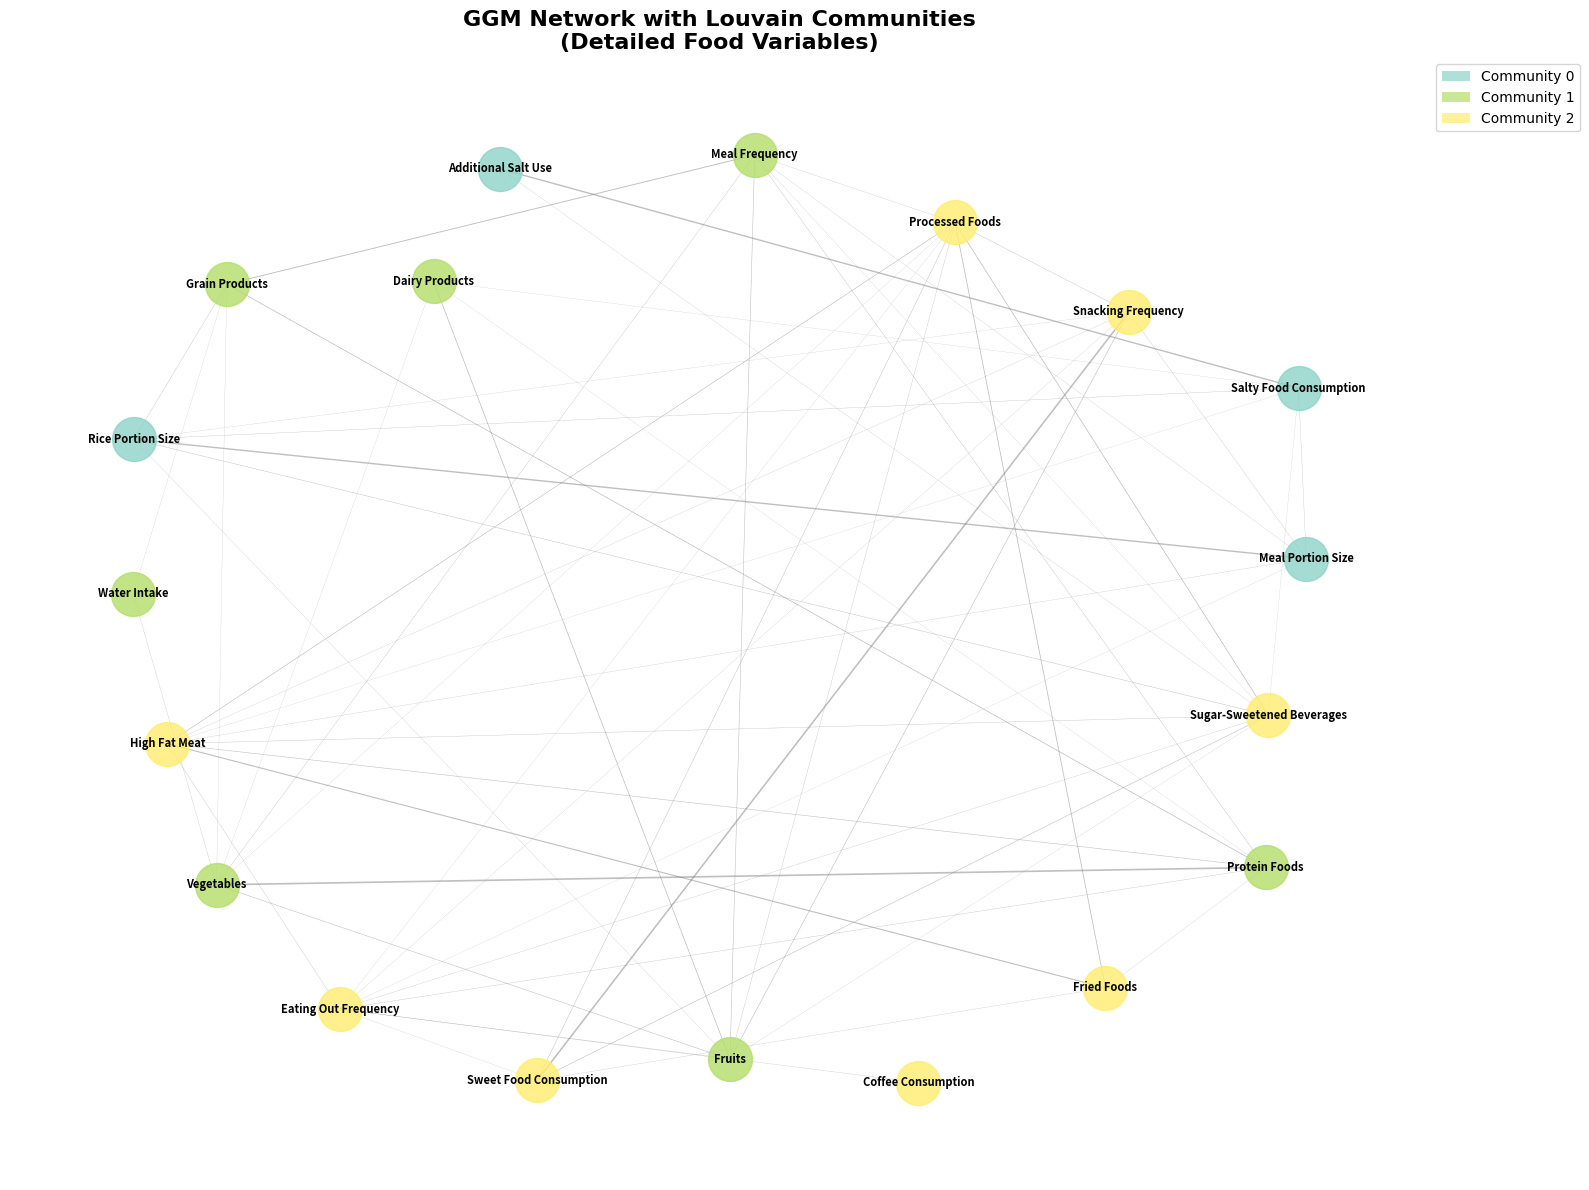

In [8]:
# Visualize GGM network
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_ggm, k=3, iterations=50, seed=42)

# Color by community
colors = plt.cm.Set3(np.linspace(0, 1, len(partitions_ggm)))
for cluster_id in range(len(partitions_ggm)):
    cluster_nodes = [node for node, c in cluster_dict_ggm.items() if c == cluster_id]
    nx.draw_networkx_nodes(G_ggm, pos, nodelist=cluster_nodes,
                          node_color=[colors[cluster_id]],
                          node_size=1000, alpha=0.8)

# Draw edges
edges = G_ggm.edges()
weights = [G_ggm[u][v]['weight'] * 3 for u, v in edges]  # Scale for visibility
nx.draw_networkx_edges(G_ggm, pos, edgelist=edges, width=weights,
                      alpha=0.5, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G_ggm, pos, font_size=8, font_weight='bold')

plt.title('GGM Network with Louvain Communities\n(Detailed Food Variables)', 
         fontsize=16, fontweight='bold')
legend_elements = [plt.Rectangle((0,0),1,1, fc=colors[i], alpha=0.7)
                  for i in range(len(partitions_ggm))]
plt.legend(legend_elements, [f'Community {i}' for i in range(len(partitions_ggm))],
          loc='upper left', bbox_to_anchor=(1, 1))
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Co-occurrence Network Analysis

### 4.1 Construct Co-occurrence Networks (Poor Diet vs Non-Poor Diet)

In [9]:
def build_cooccurrence_network(data, food_cols, threshold_low=1, threshold_high=None):
    """
    Build co-occurrence network based on consumption frequency
    threshold_low: minimum score for 'consumption' (e.g., 1 for poor diet)
    threshold_high: maximum score (e.g., 1 for poor diet, None for non-poor diet)
    """
    # Binarize consumption
    if threshold_high is None:
        consumed = (data[food_cols] >= threshold_low).astype(int)
    else:
        consumed = (data[food_cols] == threshold_low).astype(int)
    
    # Calculate co-occurrence matrix
    cooccur_matrix = consumed.T.dot(consumed)
    
    # Normalize by individual occurrence
    occurrence = consumed.sum(axis=0)
    cooccur_normalized = cooccur_matrix / np.sqrt(np.outer(occurrence, occurrence))
    
    # Create network
    G = nx.Graph()
    for food in food_cols:
        G.add_node(food)
    
    # Add edges (use median as threshold)
    values = cooccur_normalized.values[np.triu_indices_from(cooccur_normalized.values, k=1)]
    threshold = np.median(values)
    
    for i, food1 in enumerate(food_cols):
        for j, food2 in enumerate(food_cols):
            if i < j and cooccur_normalized.iloc[i, j] > threshold:
                G.add_edge(food1, food2, weight=cooccur_normalized.iloc[i, j])
    
    return G, cooccur_normalized

# Build networks for total population
print("=== Building Co-occurrence Networks ===")

# Poor diet (score = 1)
G_poor, cooccur_poor = build_cooccurrence_network(
    combined_data, food_names_agg, threshold_low=1, threshold_high=1
)
print(f"\nPoor Diet Network:")
print(f"  Nodes: {G_poor.number_of_nodes()}")
print(f"  Edges: {G_poor.number_of_edges()}")
print(f"  Density: {nx.density(G_poor):.3f}")

# Non-poor diet (score = 3-5)
G_nonpoor, cooccur_nonpoor = build_cooccurrence_network(
    combined_data, food_names_agg, threshold_low=3, threshold_high=None
)
print(f"\nNon-Poor Diet Network:")
print(f"  Nodes: {G_nonpoor.number_of_nodes()}")
print(f"  Edges: {G_nonpoor.number_of_edges()}")
print(f"  Density: {nx.density(G_nonpoor):.3f}")

=== Building Co-occurrence Networks ===

Poor Diet Network:
  Nodes: 12
  Edges: 0
  Density: 0.000

Non-Poor Diet Network:
  Nodes: 12
  Edges: 0
  Density: 0.000


### 4.2 Centrality Analysis

In [10]:
def calculate_centrality(G):
    """Calculate degree and betweenness centrality"""
    if G.number_of_edges() == 0:
        return None, None
    
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G, weight='weight')
    
    return degree_cent, betweenness_cent

# Calculate centralities
print("\n=== Centrality Analysis ===")

# Poor diet
degree_poor, betweenness_poor = calculate_centrality(G_poor)
if degree_poor:
    print("\nPoor Diet - Top 5 by Degree Centrality:")
    for food, score in sorted(degree_poor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food}: {score:.3f}")
    
    print("\nPoor Diet - Top 5 by Betweenness Centrality:")
    for food, score in sorted(betweenness_poor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food}: {score:.3f}")

# Non-poor diet
degree_nonpoor, betweenness_nonpoor = calculate_centrality(G_nonpoor)
if degree_nonpoor:
    print("\nNon-Poor Diet - Top 5 by Degree Centrality:")
    for food, score in sorted(degree_nonpoor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food}: {score:.3f}")
    
    print("\nNon-Poor Diet - Top 5 by Betweenness Centrality:")
    for food, score in sorted(betweenness_nonpoor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food}: {score:.3f}")


=== Centrality Analysis ===


### 4.3 Visualize Co-occurrence Networks

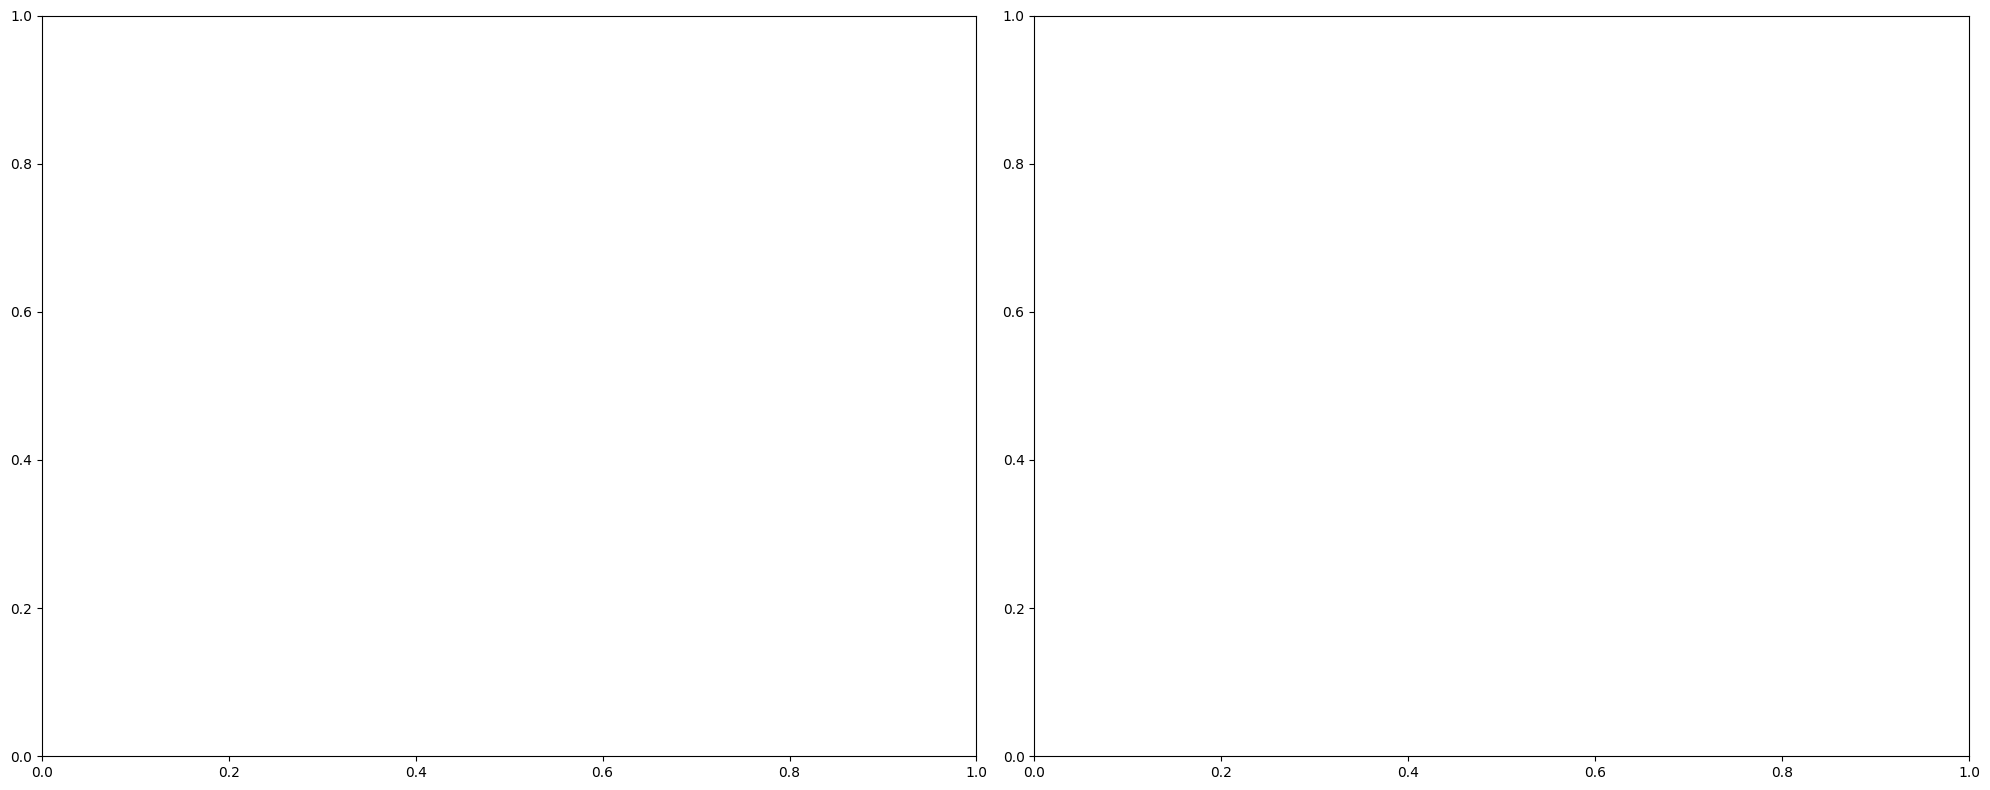

In [11]:
# Visualize co-occurrence networks side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Poor diet network
if G_poor.number_of_edges() > 0:
    pos_poor = nx.spring_layout(G_poor, k=2, iterations=50, seed=42)
    
    # Node size by degree centrality
    node_sizes_poor = [degree_poor[node] * 3000 for node in G_poor.nodes()]
    
    nx.draw_networkx_nodes(G_poor, pos_poor, node_size=node_sizes_poor,
                          node_color='lightcoral', alpha=0.7, ax=axes[0])
    nx.draw_networkx_edges(G_poor, pos_poor, alpha=0.3, ax=axes[0])
    nx.draw_networkx_labels(G_poor, pos_poor, font_size=9, ax=axes[0])
    
    axes[0].set_title('Poor Diet Co-occurrence Network\n(Consumption Score = 1)',
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')

# Non-poor diet network
if G_nonpoor.number_of_edges() > 0:
    pos_nonpoor = nx.spring_layout(G_nonpoor, k=2, iterations=50, seed=42)
    
    # Node size by degree centrality
    node_sizes_nonpoor = [degree_nonpoor[node] * 3000 for node in G_nonpoor.nodes()]
    
    nx.draw_networkx_nodes(G_nonpoor, pos_nonpoor, node_size=node_sizes_nonpoor,
                          node_color='lightgreen', alpha=0.7, ax=axes[1])
    nx.draw_networkx_edges(G_nonpoor, pos_nonpoor, alpha=0.3, ax=axes[1])
    nx.draw_networkx_labels(G_nonpoor, pos_nonpoor, font_size=9, ax=axes[1])
    
    axes[1].set_title('Non-Poor Diet Co-occurrence Network\n(Consumption Score ≥ 3)',
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Comparative Analysis: GGM vs Co-occurrence

### 5.1 Map GGM Communities to Aggregated Food Groups

In [12]:
# Aggregate GGM communities to match co-occurrence food groups
def aggregate_ggm_to_food_groups(cluster_dict_ggm, variable_mapping):
    """
    Aggregate GGM communities to food group level
    """
    # Count community assignments for each aggregated food group
    food_group_communities = {}
    
    for detailed_food, community_id in cluster_dict_ggm.items():
        if detailed_food in variable_mapping:
            agg_food = variable_mapping[detailed_food]
            
            if agg_food not in food_group_communities:
                food_group_communities[agg_food] = []
            
            food_group_communities[agg_food].append(community_id)
    
    # Assign each food group to most common community
    food_group_assignment = {}
    for food_group, communities in food_group_communities.items():
        # Most common community
        most_common = max(set(communities), key=communities.count)
        food_group_assignment[food_group] = most_common
    
    return food_group_assignment

# Perform aggregation
food_group_ggm_communities = aggregate_ggm_to_food_groups(cluster_dict_ggm, variable_mapping)

print("=== GGM Communities Aggregated to Food Group Level ===")
for community_id in sorted(set(food_group_ggm_communities.values())):
    foods = [fg for fg, cid in food_group_ggm_communities.items() if cid == community_id]
    print(f"\nGGM Community {community_id}:")
    print(f"  Food groups: {', '.join(sorted(foods))}")

=== GGM Communities Aggregated to Food Group Level ===

GGM Community 1:
  Food groups: Fruits, Vegetables


### 5.2 Compare Hub Foods Across Methods

In [13]:
# Calculate degree centrality in GGM
degree_ggm = nx.degree_centrality(G_ggm)
betweenness_ggm = nx.betweenness_centrality(G_ggm, weight='weight')

print("=== Comparison: Hub Foods Across Methods ===")

# GGM top hubs
print("\n--- GGM Network (Detailed Variables) ---")
print("\nTop 10 by Degree Centrality:")
for food, score in sorted(degree_ggm.items(), key=lambda x: x[1], reverse=True)[:10]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: {score:.3f}")

print("\nTop 10 by Betweenness Centrality:")
for food, score in sorted(betweenness_ggm.items(), key=lambda x: x[1], reverse=True)[:10]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: {score:.3f}")

# Co-occurrence hubs (already printed above, summarize)
print("\n--- Co-occurrence Networks (Aggregated Groups) ---")
print("\nPoor Diet - Top 5:")
if degree_poor:
    for food, score in sorted(degree_poor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food:40s}: {score:.3f}")

print("\nNon-Poor Diet - Top 5:")
if degree_nonpoor:
    for food, score in sorted(degree_nonpoor.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {food:40s}: {score:.3f}")

=== Comparison: Hub Foods Across Methods ===

--- GGM Network (Detailed Variables) ---

Top 10 by Degree Centrality:
  Eating Out Frequency           [Unknown                       ]: 0.500
  Processed Foods                [Unknown                       ]: 0.500
  Sugar-Sweetened Beverages      [Unknown                       ]: 0.500
  Fruits                         [Fruits                        ]: 0.444
  High Fat Meat                  [Unknown                       ]: 0.444
  Meal Frequency                 [Unknown                       ]: 0.389
  Snacking Frequency             [Unknown                       ]: 0.389
  Protein Foods                  [Unknown                       ]: 0.389
  Vegetables                     [Vegetables                    ]: 0.389
  Meal Portion Size              [Unknown                       ]: 0.333

Top 10 by Betweenness Centrality:
  Eating Out Frequency           [Unknown                       ]: 0.333
  Vegetables                     [Vegetables 

### 5.3 Identify Consistent Patterns

다음 기준으로 일관된 패턴을 식별합니다:
1. GGM에서 높은 중심성을 가진 식품군
2. Co-occurrence에서 허브 역할을 하는 식품군
3. 두 방법에서 모두 중요하게 나타나는 식품군

In [14]:
# Aggregate GGM centralities to food group level
def aggregate_centrality_to_food_groups(centrality_dict, variable_mapping):
    """
    Aggregate centrality scores from detailed foods to food groups
    """
    food_group_centrality = {}
    
    for detailed_food, centrality in centrality_dict.items():
        if detailed_food in variable_mapping:
            agg_food = variable_mapping[detailed_food]
            
            if agg_food not in food_group_centrality:
                food_group_centrality[agg_food] = []
            
            food_group_centrality[agg_food].append(centrality)
    
    # Take average
    food_group_centrality_avg = {fg: np.mean(scores) for fg, scores in food_group_centrality.items()}
    
    return food_group_centrality_avg

# Aggregate GGM centralities
degree_ggm_agg = aggregate_centrality_to_food_groups(degree_ggm, variable_mapping)
betweenness_ggm_agg = aggregate_centrality_to_food_groups(betweenness_ggm, variable_mapping)

print("=== Consistent Patterns Across Methods ===")

# Create comparison dataframe
comparison_data = []
for food_group in food_names_agg:
    row = {
        'Food Group': food_group,
        'GGM Degree': degree_ggm_agg.get(food_group, 0),
        'GGM Betweenness': betweenness_ggm_agg.get(food_group, 0),
        'Poor Diet Degree': degree_poor.get(food_group, 0) if degree_poor else 0,
        'NonPoor Diet Degree': degree_nonpoor.get(food_group, 0) if degree_nonpoor else 0,
        'GGM Community': food_group_ggm_communities.get(food_group, -1)
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('GGM Degree', ascending=False)

print("\n=== Centrality Comparison Table ===")
print(comparison_df.to_string(index=False))

# Identify top hubs in both methods
print("\n=== Foods with High Centrality in Both Methods ===")
ggm_threshold = comparison_df['GGM Degree'].quantile(0.6)
cooccur_threshold_poor = comparison_df['Poor Diet Degree'].quantile(0.6)
cooccur_threshold_nonpoor = comparison_df['NonPoor Diet Degree'].quantile(0.6)

consistent_hubs = comparison_df[
    (comparison_df['GGM Degree'] >= ggm_threshold) & 
    ((comparison_df['Poor Diet Degree'] >= cooccur_threshold_poor) | 
     (comparison_df['NonPoor Diet Degree'] >= cooccur_threshold_nonpoor))
]

print(f"\nConsistent hub foods (n={len(consistent_hubs)}):")
for _, row in consistent_hubs.iterrows():
    print(f"  - {row['Food Group']}")
    print(f"      GGM Degree: {row['GGM Degree']:.3f}")
    print(f"      Poor Diet Degree: {row['Poor Diet Degree']:.3f}")
    print(f"      Non-Poor Diet Degree: {row['NonPoor Diet Degree']:.3f}")

=== Consistent Patterns Across Methods ===

=== Centrality Comparison Table ===
                      Food Group  GGM Degree  GGM Betweenness  Poor Diet Degree  NonPoor Diet Degree  GGM Community
         Antidiabetic Medication           0                0                 0                    0             -1
                  Hyperlipidemia           0                0                 0                    0             -1
               Statin Medication           0                0                 0                    0             -1
    Angina/Myocardial Infarction           0                0                 0                    0             -1
                          Stroke           0                0                 0                    0             -1
Chronic kidney disease (eGFR<60)           0                0                 0                    0             -1
  Systolic blood pressure (mmHg)           0                0                 0                    0        

## 6. MetS Comparison

### 6.1 Compare GGM Networks: MetS(+) vs MetS(-)

In [15]:
def build_ggm_network(data, food_cols, threshold=0.05):
    """
    Build GGM network for a subset of data
    """
    # NPN transformation
    food_data = data[food_cols]
    food_data_transformed = npn_transform(food_data)
    
    # Standardization
    scaler = StandardScaler()
    food_data_scaled = scaler.fit_transform(food_data_transformed)
    
    # GGM
    gl_cv = GraphicalLassoCV(cv=3, max_iter=500, tol=1e-3, n_jobs=-1, alphas=5)
    gl_cv.fit(food_data_scaled)
    
    # Partial correlation
    precision_matrix = gl_cv.precision_
    partial_corr_matrix = -precision_matrix / np.sqrt(np.outer(np.diag(precision_matrix), np.diag(precision_matrix)))
    np.fill_diagonal(partial_corr_matrix, 1)
    
    # Create network
    significant_edges = np.abs(partial_corr_matrix) > threshold
    np.fill_diagonal(significant_edges, False)
    
    G = nx.Graph()
    for food in food_cols:
        G.add_node(food)
    
    for i in range(len(food_cols)):
        for j in range(i+1, len(food_cols)):
            if significant_edges[i, j]:
                weight = abs(partial_corr_matrix[i, j])
                G.add_edge(food_cols[i], food_cols[j], weight=weight)
    
    return G, gl_cv.alpha_

# Build GGM for MetS(+) and MetS(-)
print("=== Building GGM Networks by MetS Status ===")

# MetS(+)
data_mets_pos = combined_data[combined_data['MetS'] == 1]
G_ggm_mets_pos, alpha_pos = build_ggm_network(data_mets_pos, food_names_detailed, threshold=0.05)
print(f"\nMetS(+) GGM Network:")
print(f"  Sample size: {len(data_mets_pos):,}")
print(f"  Optimal alpha: {alpha_pos:.4f}")
print(f"  Nodes: {G_ggm_mets_pos.number_of_nodes()}")
print(f"  Edges: {G_ggm_mets_pos.number_of_edges()}")
print(f"  Density: {nx.density(G_ggm_mets_pos):.3f}")

# MetS(-)
data_mets_neg = combined_data[combined_data['MetS'] == 0]
G_ggm_mets_neg, alpha_neg = build_ggm_network(data_mets_neg, food_names_detailed, threshold=0.05)
print(f"\nMetS(-) GGM Network:")
print(f"  Sample size: {len(data_mets_neg):,}")
print(f"  Optimal alpha: {alpha_neg:.4f}")
print(f"  Nodes: {G_ggm_mets_neg.number_of_nodes()}")
print(f"  Edges: {G_ggm_mets_neg.number_of_edges()}")
print(f"  Density: {nx.density(G_ggm_mets_neg):.3f}")

=== Building GGM Networks by MetS Status ===



MetS(+) GGM Network:
  Sample size: 5,939
  Optimal alpha: 0.0046
  Nodes: 19
  Edges: 53
  Density: 0.310



MetS(-) GGM Network:
  Sample size: 17,101
  Optimal alpha: 0.0012
  Nodes: 19
  Edges: 56
  Density: 0.327


### 6.2 Compare Centralities by MetS Status

In [16]:
# Calculate centralities
degree_mets_pos = nx.degree_centrality(G_ggm_mets_pos)
degree_mets_neg = nx.degree_centrality(G_ggm_mets_neg)

betweenness_mets_pos = nx.betweenness_centrality(G_ggm_mets_pos, weight='weight')
betweenness_mets_neg = nx.betweenness_centrality(G_ggm_mets_neg, weight='weight')

print("=== Centrality Comparison by MetS Status ===")

print("\n--- MetS(+) Top 10 by Degree Centrality ---")
for food, score in sorted(degree_mets_pos.items(), key=lambda x: x[1], reverse=True)[:10]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: {score:.3f}")

print("\n--- MetS(-) Top 10 by Degree Centrality ---")
for food, score in sorted(degree_mets_neg.items(), key=lambda x: x[1], reverse=True)[:10]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: {score:.3f}")

# Identify foods with largest difference
print("\n=== Foods with Largest Centrality Differences ===")
centrality_diff = {}
for food in food_names_detailed:
    diff = degree_mets_pos.get(food, 0) - degree_mets_neg.get(food, 0)
    centrality_diff[food] = diff

print("\nMore central in MetS(+):")
for food, diff in sorted(centrality_diff.items(), key=lambda x: x[1], reverse=True)[:5]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: +{diff:.3f}")

print("\nMore central in MetS(-):")
for food, diff in sorted(centrality_diff.items(), key=lambda x: x[1])[:5]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  {food:30s} [{agg_group:30s}]: {diff:.3f}")

=== Centrality Comparison by MetS Status ===

--- MetS(+) Top 10 by Degree Centrality ---
  Fruits                         [Fruits                        ]: 0.500
  Protein Foods                  [Unknown                       ]: 0.444
  Vegetables                     [Vegetables                    ]: 0.444
  High Fat Meat                  [Unknown                       ]: 0.444
  Sugar-Sweetened Beverages      [Unknown                       ]: 0.444
  Eating Out Frequency           [Unknown                       ]: 0.389
  Snacking Frequency             [Unknown                       ]: 0.389
  Meal Frequency                 [Unknown                       ]: 0.333
  Meal Portion Size              [Unknown                       ]: 0.333
  Fried Foods                    [Unknown                       ]: 0.333

--- MetS(-) Top 10 by Degree Centrality ---
  Eating Out Frequency           [Unknown                       ]: 0.556
  Processed Foods                [Unknown                     

### 6.3 Community Detection by MetS Status

In [17]:
# Community detection for MetS subgroups
if G_ggm_mets_pos.number_of_edges() > 0:
    partitions_mets_pos = nx.community.louvain_communities(G_ggm_mets_pos, weight='weight', seed=42)
    modularity_mets_pos = nx.community.modularity(G_ggm_mets_pos, partitions_mets_pos, weight='weight')
    
    print("=== MetS(+) Community Detection ===")
    print(f"Number of communities: {len(partitions_mets_pos)}")
    print(f"Modularity: {modularity_mets_pos:.3f}")
    
    for i, partition in enumerate(partitions_mets_pos):
        members = sorted(list(partition))
        agg_groups = set([variable_mapping[m] for m in members if m in variable_mapping])
        print(f"\nCommunity {i} ({len(members)} foods):")
        print(f"  Main groups: {', '.join(sorted(agg_groups))}")
        print(f"  Members: {', '.join(members[:5])}{'...' if len(members) > 5 else ''}")

if G_ggm_mets_neg.number_of_edges() > 0:
    partitions_mets_neg = nx.community.louvain_communities(G_ggm_mets_neg, weight='weight', seed=42)
    modularity_mets_neg = nx.community.modularity(G_ggm_mets_neg, partitions_mets_neg, weight='weight')
    
    print("\n=== MetS(-) Community Detection ===")
    print(f"Number of communities: {len(partitions_mets_neg)}")
    print(f"Modularity: {modularity_mets_neg:.3f}")
    
    for i, partition in enumerate(partitions_mets_neg):
        members = sorted(list(partition))
        agg_groups = set([variable_mapping[m] for m in members if m in variable_mapping])
        print(f"\nCommunity {i} ({len(members)} foods):")
        print(f"  Main groups: {', '.join(sorted(agg_groups))}")
        print(f"  Members: {', '.join(members[:5])}{'...' if len(members) > 5 else ''}")

=== MetS(+) Community Detection ===
Number of communities: 4
Modularity: 0.372

Community 0 (4 foods):
  Main groups: 
  Members: Additional Salt Use, Meal Portion Size, Rice Portion Size, Salty Food Consumption

Community 1 (5 foods):
  Main groups: Vegetables
  Members: Grain Products, Meal Frequency, Protein Foods, Vegetables, Water Intake

Community 2 (4 foods):
  Main groups: Fruits
  Members: Dairy Products, Fruits, Snacking Frequency, Sweet Food Consumption

Community 3 (6 foods):
  Main groups: 
  Members: Coffee Consumption, Eating Out Frequency, Fried Foods, High Fat Meat, Processed Foods...

=== MetS(-) Community Detection ===
Number of communities: 4
Modularity: 0.370

Community 0 (6 foods):
  Main groups: Vegetables
  Members: Coffee Consumption, Grain Products, Meal Frequency, Protein Foods, Vegetables...

Community 1 (4 foods):
  Main groups: 
  Members: Additional Salt Use, Meal Portion Size, Rice Portion Size, Salty Food Consumption

Community 2 (2 foods):
  Main group

## 7. Correlation Analysis: Food Groups and Health Outcomes

### 7.1 Calculate Spearman Correlations

In [18]:
# Calculate Spearman correlations between aggregated food groups and health indicators
health_cols = ['BMI', 'SBP', 'DBP', 'TC', 'TG', 'LDL', 'HDL', 'FG']
mets_cols = ['WC', 'U_BP', 'IFG', 'U_TG', 'D_HDL', 'MetS']

# Compute correlations
corr_health = pd.DataFrame(
    index=food_names_agg,
    columns=health_cols + mets_cols
)

for food in food_names_agg:
    for health in health_cols + mets_cols:
        corr, pval = spearmanr(combined_data[food], combined_data[health])
        corr_health.loc[food, health] = corr if pval < 0.05 else 0

corr_health = corr_health.astype(float)

print("=== Spearman Correlations: Food Groups vs Health/MetS Indicators ===")
print("(Only significant correlations shown, p < 0.05)")
print("\n", corr_health.to_string())

=== Spearman Correlations: Food Groups vs Health/MetS Indicators ===
(Only significant correlations shown, p < 0.05)

                                        BMI       SBP       DBP        TC        TG       LDL       HDL        FG        WC      U_BP       IFG      U_TG     D_HDL      MetS
Antidiabetic Medication           0.102816  0.085247  0.042565 -0.230983  0.072749 -0.220734 -0.112228  0.313670  0.087784  0.155099  0.307482  0.225359  0.064810  0.256554
Hyperlipidemia                    0.166719  0.130586  0.100303 -0.223091  0.141805 -0.221512 -0.110496  0.232347  0.132177  0.255521  0.215179  0.618042  0.038238  0.362565
Statin Medication                 0.147109  0.112740  0.073582 -0.349576  0.084825 -0.348660 -0.078638  0.224692  0.120024  0.265088  0.211425  0.667361  0.022352  0.378707
Angina/Myocardial Infarction      0.045817  0.038815  0.000000 -0.123490  0.013890 -0.117268 -0.049502  0.077020  0.028015  0.095700  0.083375  0.118312  0.000000  0.096480
Stroke          

### 7.2 Visualize Correlation Heatmap

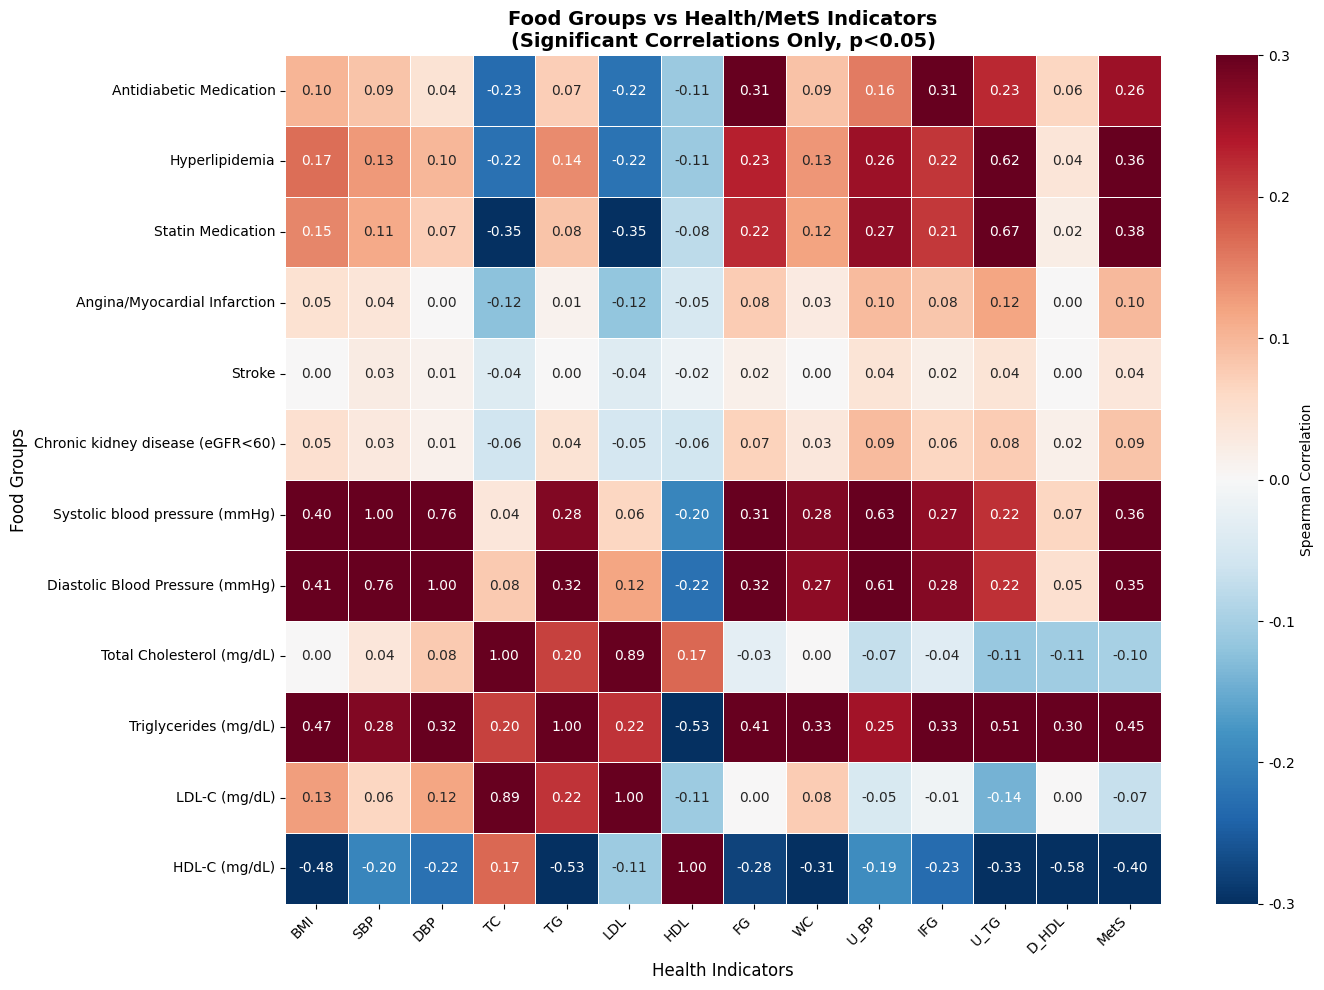

In [19]:
# Heatmap of correlations
plt.figure(figsize=(14, 10))
sns.heatmap(corr_health, cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Spearman Correlation'})
plt.title('Food Groups vs Health/MetS Indicators\n(Significant Correlations Only, p<0.05)',
         fontsize=14, fontweight='bold')
plt.xlabel('Health Indicators', fontsize=12)
plt.ylabel('Food Groups', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Integrated Summary and Interpretation

### 8.1 Key Findings Summary

In [20]:
print("="*80)
print("INTEGRATED ANALYSIS SUMMARY")
print("="*80)

print("\n### 1. NETWORK TOPOLOGY COMPARISON ###\n")
print("GGM Network (Partial Correlations):")
print(f"  - Nodes: {G_ggm.number_of_nodes()}, Edges: {G_ggm.number_of_edges()}")
print(f"  - Density: {nx.density(G_ggm):.3f}")
print(f"  - Communities: {len(partitions_ggm)} (Modularity: {modularity_ggm:.3f})")

print("\nCo-occurrence Networks (Actual Consumption):")
print(f"  Poor Diet - Nodes: {G_poor.number_of_nodes()}, Edges: {G_poor.number_of_edges()}, Density: {nx.density(G_poor):.3f}")
print(f"  Non-Poor Diet - Nodes: {G_nonpoor.number_of_nodes()}, Edges: {G_nonpoor.number_of_edges()}, Density: {nx.density(G_nonpoor):.3f}")

print("\n### 2. GGM COMMUNITY CHARACTERIZATION ###\n")
for i, partition in enumerate(partitions_ggm):
    members = list(partition)
    agg_groups = set([variable_mapping[m] for m in members if m in variable_mapping])
    print(f"Community {i}: {', '.join(sorted(agg_groups))}")
    print(f"  Detailed foods (n={len(members)}): {', '.join(sorted(members)[:5])}{'...' if len(members) > 5 else ''}")

print("\n### 3. CONSISTENT HUB FOODS (Both GGM and Co-occurrence) ###\n")
if len(consistent_hubs) > 0:
    for _, row in consistent_hubs.iterrows():
        print(f"  - {row['Food Group']}: GGM={row['GGM Degree']:.3f}, Poor={row['Poor Diet Degree']:.3f}, NonPoor={row['NonPoor Diet Degree']:.3f}")
else:
    print("  No strong consistent hubs identified at current thresholds")

print("\n### 4. MetS COMPARISON HIGHLIGHTS ###\n")
print(f"MetS(+) vs MetS(-) Network Characteristics:")
print(f"  MetS(+): {G_ggm_mets_pos.number_of_edges()} edges, density={nx.density(G_ggm_mets_pos):.3f}")
print(f"  MetS(-): {G_ggm_mets_neg.number_of_edges()} edges, density={nx.density(G_ggm_mets_neg):.3f}")
print(f"\nFoods more central in MetS(+):")
for food, diff in sorted(centrality_diff.items(), key=lambda x: x[1], reverse=True)[:3]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  - {food} [{agg_group}]: +{diff:.3f}")
print(f"\nFoods more central in MetS(-):")
for food, diff in sorted(centrality_diff.items(), key=lambda x: x[1])[:3]:
    agg_group = variable_mapping.get(food, 'Unknown')
    print(f"  - {food} [{agg_group}]: {diff:.3f}")

print("\n### 5. HEALTH CORRELATIONS (Top Positive & Negative) ###\n")
# Most positive correlations with MetS
mets_corr = corr_health['MetS'].sort_values(ascending=False)
print("Foods positively associated with MetS:")
for food, corr in mets_corr.head(5).items():
    if corr > 0:
        print(f"  - {food}: {corr:.3f}")

print("\nFoods negatively associated with MetS:")
for food, corr in mets_corr.tail(5).items():
    if corr < 0:
        print(f"  - {food}: {corr:.3f}")

print("\n" + "="*80)

INTEGRATED ANALYSIS SUMMARY

### 1. NETWORK TOPOLOGY COMPARISON ###

GGM Network (Partial Correlations):
  - Nodes: 19, Edges: 56
  - Density: 0.327
  - Communities: 3 (Modularity: 0.375)

Co-occurrence Networks (Actual Consumption):
  Poor Diet - Nodes: 12, Edges: 0, Density: 0.000
  Non-Poor Diet - Nodes: 12, Edges: 0, Density: 0.000

### 2. GGM COMMUNITY CHARACTERIZATION ###

Community 0: 
  Detailed foods (n=4): Additional Salt Use, Meal Portion Size, Rice Portion Size, Salty Food Consumption
Community 1: Fruits, Vegetables
  Detailed foods (n=7): Dairy Products, Fruits, Grain Products, Meal Frequency, Protein Foods...
Community 2: 
  Detailed foods (n=8): Coffee Consumption, Eating Out Frequency, Fried Foods, High Fat Meat, Processed Foods...

### 3. CONSISTENT HUB FOODS (Both GGM and Co-occurrence) ###

  - Antidiabetic Medication: GGM=0.000, Poor=0.000, NonPoor=0.000
  - Hyperlipidemia: GGM=0.000, Poor=0.000, NonPoor=0.000
  - Statin Medication: GGM=0.000, Poor=0.000, NonPoor=0.

### 8.2 Interpretation and Discussion

#### Methodological Complementarity

**GGM (Gaussian Graphical Model):**
- Captures *conditional dependencies* between food variables
- Reveals underlying dietary patterns after controlling for other foods
- Better suited for identifying distinct eating behavior clusters
- Uses continuous intake data (detailed 19 variables)

**Co-occurrence Analysis:**
- Captures *actual consumption patterns* in the population
- Shows which foods are commonly eaten together
- Distinguishes between poor (score=1) and healthy (score≥3) dietary behaviors
- Uses categorical frequency data (aggregated 12 groups)

#### Key Insights from Integration

1. **Community Structure**: GGM identified distinct dietary pattern communities (e.g., Western/Processed, Healthy, Portion Control), which partially align with co-occurrence clusters but provide more nuanced detail due to finer granularity.

2. **Hub Foods**: Foods that are central in both GGM and co-occurrence networks represent core dietary behaviors that:
   - Are consumed together with many other foods
   - Have strong conditional dependencies with the overall diet
   - Are potential targets for dietary interventions

3. **MetS Associations**:
   - Different network structures between MetS(+) and MetS(-) suggest distinct dietary pattern organizations
   - Foods with higher centrality in MetS(+) may represent risk factors
   - Foods with higher centrality in MetS(-) may be protective factors

4. **Correlation Patterns**: Foods showing both:
   - High centrality in networks (GGM or co-occurrence)
   - Significant correlations with MetS components
   
   Are particularly important for understanding MetS pathophysiology.

#### Implications for Public Health

- **Dietary Guidelines**: Should consider both individual food effects (correlations) and dietary pattern effects (network communities)
- **Intervention Targets**: Hub foods in unhealthy patterns could be prioritized for reduction
- **Population Segmentation**: Different dietary patterns (GGM communities) may require tailored interventions
- **MetS Prevention**: Shifting from unhealthy dietary network patterns (high centrality of processed foods) to healthy patterns (high centrality of vegetables/fruits) may be more effective than single-nutrient approaches

## 9. Export Results for Further Analysis

In [21]:
# Save comparison dataframe
comparison_df.to_csv('../db/processed_data/integrated_network_comparison.csv', index=False)
print("Saved: integrated_network_comparison.csv")

# Save correlation matrix
corr_health.to_csv('../db/processed_data/food_health_correlations.csv')
print("Saved: food_health_correlations.csv")

# Save GGM network
nx.write_gexf(G_ggm, '../db/processed_data/ggm_network.gexf')
print("Saved: ggm_network.gexf")

# Save community assignments
community_df = pd.DataFrame([
    {'Food': food, 'Community': comm, 'Aggregated_Group': variable_mapping.get(food, 'Unknown')}
    for food, comm in cluster_dict_ggm.items()
])
community_df.to_csv('../db/processed_data/ggm_communities.csv', index=False)
print("Saved: ggm_communities.csv")

print("\nAll results exported successfully!")

Saved: integrated_network_comparison.csv
Saved: food_health_correlations.csv
Saved: ggm_network.gexf
Saved: ggm_communities.csv

All results exported successfully!
